In [1]:
import joblib
import numpy as np
import pandas as pd

X_train = joblib.load("../features/X_train.pkl")
X_val = joblib.load("../features/X_val.pkl")
X_test = joblib.load("../features/X_test.pkl")

y_train = joblib.load("../features/y_train.pkl")
y_val = joblib.load("../features/y_val.pkl")
y_test = joblib.load("../features/y_test.pkl")

print(X_train.shape)
print(y_train.shape)

(1134, 11)
(1134,)


In [2]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [4]:
val_probs = model.predict_proba(X_val)[:,1]

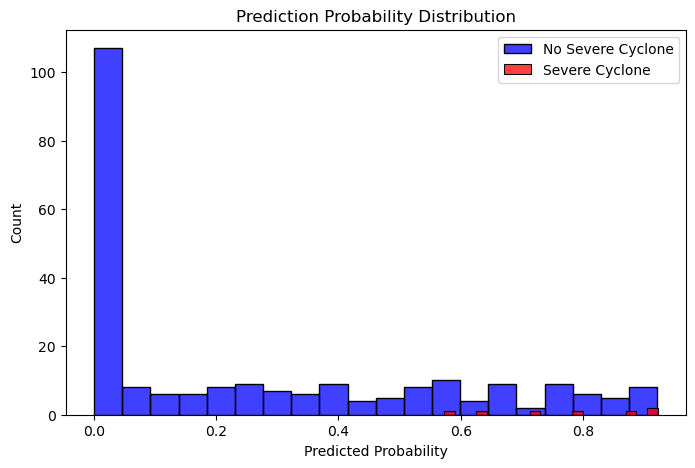

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(val_probs[y_val==0], color="blue", label="No Severe Cyclone", bins=20)
sns.histplot(val_probs[y_val==1], color="red", label="Severe Cyclone", bins=20)

plt.legend()
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.show()

In [6]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.05,0.95,50)

results = []

for t in thresholds:
    
    preds = (val_probs >= t).astype(int)
    
    precision = precision_score(y_val,preds)
    recall = recall_score(y_val,preds)
    f1 = f1_score(y_val,preds)
    
    results.append((t,precision,recall,f1))

results = np.array(results)

e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


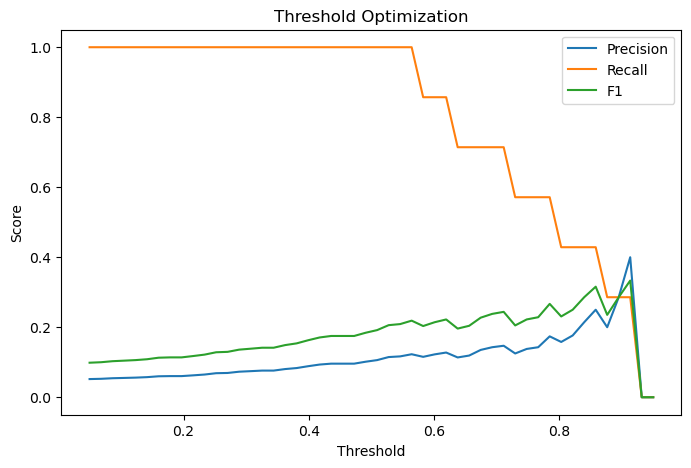

In [7]:
plt.figure(figsize=(8,5))

plt.plot(results[:,0],results[:,1],label="Precision")
plt.plot(results[:,0],results[:,2],label="Recall")
plt.plot(results[:,0],results[:,3],label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()

In [8]:
best_index = np.argmax(results[:,3])
best_threshold = results[best_index,0]

print("Best Threshold:",best_threshold)
print("Best F1:",results[best_index,3])

Best Threshold: 0.9132653061224489
Best F1: 0.3333333333333333


In [9]:

best_threshold = float(best_threshold)

val_preds = (val_probs >= best_threshold).astype(int)

In [10]:
print("Accuracy:", accuracy_score(y_val, val_preds))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1:", f1_score(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Accuracy: 0.9670781893004116
Precision: 0.4
Recall: 0.2857142857142857
F1: 0.3333333333333333
ROC-AUC: 0.9152542372881357


In [11]:
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       236
           1       0.40      0.29      0.33         7

    accuracy                           0.97       243
   macro avg       0.69      0.64      0.66       243
weighted avg       0.96      0.97      0.96       243



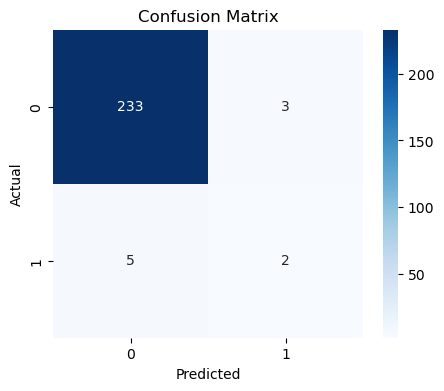

In [12]:
cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

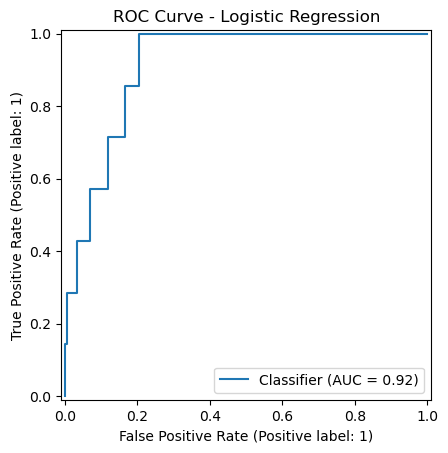

In [13]:
RocCurveDisplay.from_predictions(
    y_val,
    val_probs
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

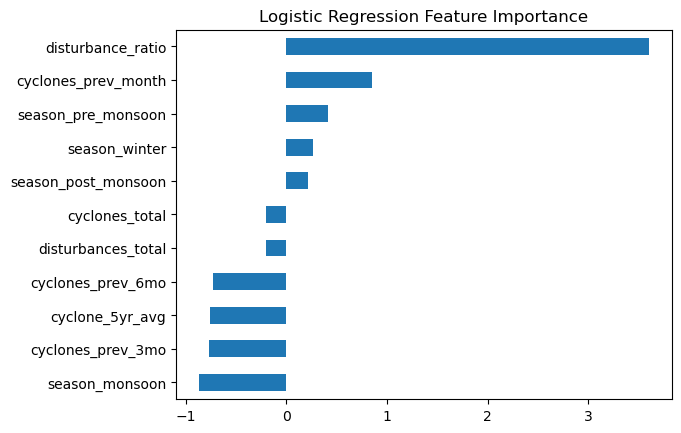

In [14]:
feature_names = [
    "cyclones_total",
    "disturbances_total",
    "disturbance_ratio",
    "cyclone_5yr_avg",
    "season_monsoon",
    "season_post_monsoon",
    "season_pre_monsoon",
    "season_winter",
    "cyclones_prev_month",
    "cyclones_prev_3mo",
    "cyclones_prev_6mo"
]

coeffs = pd.Series(
    model.coef_[0],
    index=feature_names
)

coeffs.sort_values().plot.barh()

plt.title("Logistic Regression Feature Importance")

plt.show()

In [15]:
test_preds = model.predict(X_test)
test_probs = model.predict_proba(X_test)[:,1]

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))
print("TEST F1:", f1_score(y_test, test_preds))

TEST ROC-AUC: 0.9033063006862133
TEST F1: 0.27586206896551724


In [16]:
joblib.dump(
    model,
    "../models/logistic_regression_model.pkl"
)

['../models/logistic_regression_model.pkl']